Best Model: XGBoost
Brier Score: 0.0876
Average Unemployment Probability: 30.52%


,precision,recall,f1-score,support
Employed,87.79%,92.79%,90.22%,31329.000000
Unemployed,81.12%,70.58%,75.48%,13748.000000
accuracy,86.02%,86.02%,86.02%,0.860173
macro avg,84.45%,81.69%,82.85%,45077.000000
weighted avg,85.75%,86.02%,85.73%,45077.000000


,Predicted Employed,Predicted Unemployed
Actual Employed,29071,2258
Actual Unemployed,4045,9703


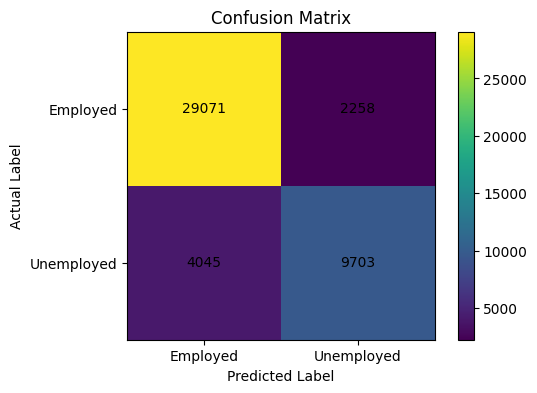

In [ ]:

# ============================================================
# 9. DETAILED EVALUATION OF BEST MODEL
# ============================================================

y_pred_best = best_pipeline.predict(X_test)
y_prob_best = best_pipeline.predict_proba(X_test)[:, 1]

brier = brier_score_loss(
    y_test,
    y_prob_best
)

print("Best Model:", best_model_name)
print("Brier Score:", round(brier, 4))
print("Average Unemployment Probability:", f"{np.mean(y_prob_best) * 100:.2f}%")

report_dict = classification_report(
    y_test,
    y_pred_best,
    target_names=["Employed", "Unemployed"],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T
for col in ["precision", "recall", "f1-score"]:
    report_df[col] = (report_df[col] * 100).round(2).astype(str) + "%"

display(report_df)

cm = confusion_matrix(y_test, y_pred_best)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Employed", "Actual Unemployed"],
    columns=["Predicted Employed", "Predicted Unemployed"]
)
display(cm_df)

plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Employed", "Unemployed"])
plt.yticks([0, 1], ["Employed", "Unemployed"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


In [ ]:

# ============================================================
# 10. CROSS VALIDATION
# ============================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=skf,
    scoring="f1",
    n_jobs=-1
)

print("5-Fold Stratified Cross Validation F1 Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score * 100:.2f}%")

print("Mean F1:", f"{cv_scores.mean() * 100:.2f}%")
print("Standard Deviation:", f"{cv_scores.std() * 100:.2f}%")


5-Fold Stratified Cross Validation F1 Scores:
Fold 1: 75.12%
Fold 2: 74.93%
Fold 3: 75.39%
Fold 4: 75.26%
Fold 5: 75.43%
Mean F1: 75.22%
Standard Deviation: 0.18%


In [ ]:

# ============================================================
# 11. OVERFITTING CHECK
# ============================================================

train_pred = best_pipeline.predict(X_train)
test_pred = best_pipeline.predict(X_test)

train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)
diff = abs(train_f1 - test_f1)

print("Training F1:", f"{train_f1 * 100:.2f}%")
print("Testing F1:", f"{test_f1 * 100:.2f}%")
print("Difference:", f"{diff * 100:.2f}%")

if diff < 0.05:
    print("Conclusion: No major overfitting detected.")
else:
    print("Conclusion: Possible overfitting; further tuning may be needed.")


Training F1: 75.76%
Testing F1: 75.48%
Difference: 0.28%
Conclusion: No major overfitting detected.


,Feature,Importance
3,Education Level Bachelor's,0.227303
4,Education Level Diploma,0.110074
14,Language Proficiency Basic,0.096396
15,Language Proficiency Fluent,0.093666
13,Language Proficiency Advanced,0.087077
16,Language Proficiency Intermediate,0.084833
5,Education Level Master's,0.066206
25,Internship Experience Yes,0.063771
6,Education Level PhD,0.051111
24,Internship Experience No,0.039062


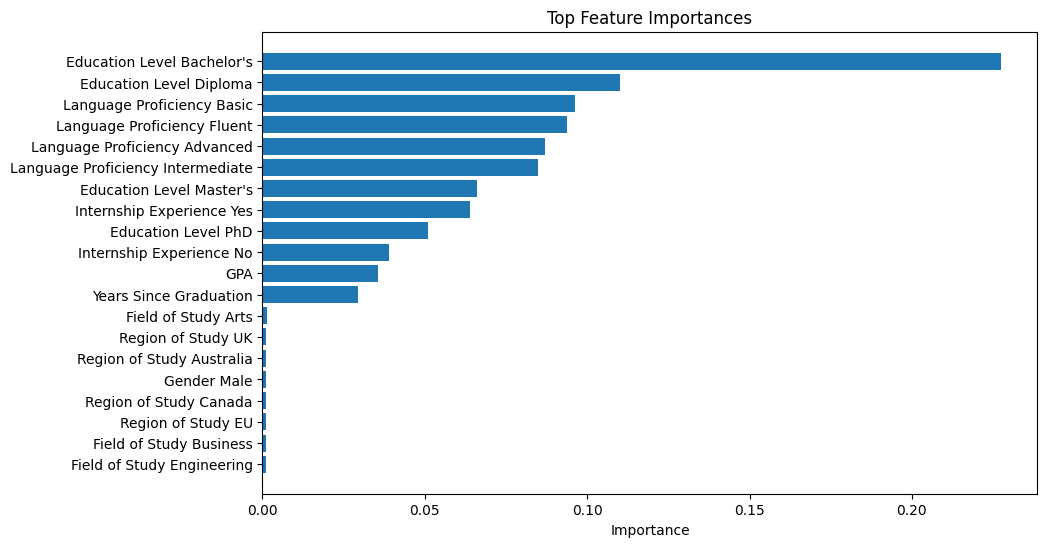

In [ ]:

# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

model = best_pipeline.named_steps["model"]
preprocessor_fitted = best_pipeline.named_steps["preprocessor"]

try:
    feature_names = preprocessor_fitted.get_feature_names_out()
    feature_names = [
        name.replace("num__", "").replace("cat__", "").replace("_", " ")
        for name in feature_names
    ]

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_[0])
    else:
        importances = None

    if importances is not None:
        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        }).sort_values(by="Importance", ascending=False).head(20)

        display(importance_df)

        plt.figure(figsize=(10, 6))
        plt.barh(importance_df["Feature"], importance_df["Importance"])
        plt.gca().invert_yaxis()
        plt.title("Top Feature Importances")
        plt.xlabel("Importance")
        plt.show()
    else:
        print("Feature importance is not available for this model.")

except Exception as e:
    print("Could not generate feature importance:", e)
